In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
SEED=42
np.random.seed(SEED)

In [4]:
df=pd.read_csv('/content/boxoffice.csv',encoding='latin-1')
df.head()

,title,domestic_revenue,world_revenue,distributor,opening_revenue,opening_theaters,budget,MPAA,genres,release_days
0,The Avengers,6026491,1274885664,Warner Bros.,163620146,253,174687337,R,Animation,16
1,Titanic,169411543,1132871091,Disney,85549990,122,103948486,G,Action,103
2,Jurassic Park,107836098,583329845,Sony,55681429,3826,122104991,NC-17,Horror,89
3,Avatar,51433697,1225323391,Disney,109775324,3868,46431596,G,Horror,85
4,The Lion King,142791649,604140729,Warner Bros.,59476800,2934,203513696,R,Comedy,158


In [5]:
df.shape

(2694, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2694 entries, 0 to 2693
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   title             2694 non-null   object
 1   domestic_revenue  2694 non-null   int64 
 2   world_revenue     2694 non-null   int64 
 3   distributor       2694 non-null   object
 4   opening_revenue   2694 non-null   int64 
 5   opening_theaters  2694 non-null   int64 
 6   budget            2694 non-null   int64 
 7   MPAA              2694 non-null   object
 8   genres            2694 non-null   object
 9   release_days      2694 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 210.6+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
domestic_revenue,2694.0,1.508539e+08,8.579997e+07,827765.0,7.673272e+07,152572473.5,2.247314e+08,2.998107e+08
world_revenue,2694.0,7.719177e+08,4.284414e+08,3261301.0,3.991135e+08,766555142.5,1.143920e+09,1.499310e+09
opening_revenue,2694.0,9.971321e+07,5.721762e+07,138569.0,5.033848e+07,99814175.0,1.489805e+08,1.999336e+08
opening_theaters,2694.0,2.263039e+03,1.298559e+03,10.0,1.161000e+03,2271.5,3.392250e+03,4.499000e+03
budget,2694.0,1.537996e+08,8.557624e+07,5197977.0,7.861876e+07,156256716.0,2.274832e+08,2.998597e+08
release_days,2694.0,9.089755e+01,5.089404e+01,1.0,4.700000e+01,91.0,1.350000e+02,1.790000e+02


In [9]:
df_new=df.drop(columns=['world_revenue','opening_revenue','opening_theaters','title','domestic_revenue','release_days'])

In [10]:
y=df['domestic_revenue']

In [11]:
print('Genres: ',df_new['genres'].nunique())
print('distributor: ',df_new['distributor'].nunique())
df_new['MPAA'].value_counts()

Genres:  6
distributor:  5


,count
MPAA,
R,556
PG-13,551
NC-17,546
G,534
PG,507


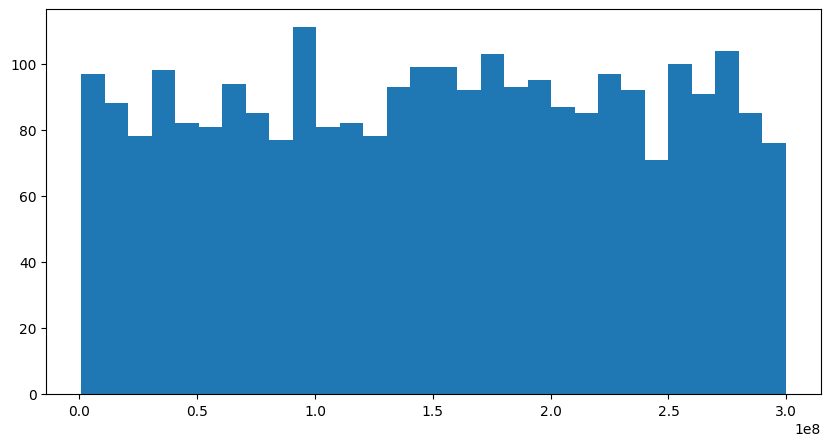

In [12]:
plt.figure(figsize=(10,5))
plt.hist(y,bins=30)
plt.show()

In [36]:
num_cols=['domestic_revenue','budget']
corr=df[num_cols].corr()
print(corr)

                  domestic_revenue    budget
domestic_revenue          1.000000 -0.021222
budget                   -0.021222  1.000000


In [14]:
df_new.head()

,distributor,budget,MPAA,genres
0,Warner Bros.,174687337,R,Animation
1,Disney,103948486,G,Action
2,Sony,122104991,NC-17,Horror
3,Disney,46431596,G,Horror
4,Warner Bros.,203513696,R,Comedy


In [19]:
X=df[['budget','genres','distributor','MPAA']]
y=df['domestic_revenue']

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((2155, 4), (539, 4), (2155,), (539,))

In [25]:
cat=['distributor','genres','MPAA']
num=['budget']
preprocessor=ColumnTransformer(
    [
        ('categorical',OneHotEncoder(handle_unknown='ignore'),cat),
        ('numerical','passthrough',num)
    ]
)
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])

In [37]:
for col in ['genres','distributor','MPAA']:
  print('\n',col)
  print(df.groupby(col)['domestic_revenue'].mean().sort_values())


 genres
genres
Drama        1.442224e+08
Animation    1.497579e+08
Thriller     1.519800e+08
Comedy       1.524603e+08
Action       1.525237e+08
Horror       1.540429e+08
Name: domestic_revenue, dtype: float64

 distributor
distributor
Disney          1.502792e+08
Sony            1.504051e+08
Warner Bros.    1.505376e+08
Paramount       1.511022e+08
Universal       1.518269e+08
Name: domestic_revenue, dtype: float64

 MPAA
MPAA
G        1.465288e+08
PG-13    1.477556e+08
NC-17    1.507193e+08
PG       1.529123e+08
R        1.563334e+08
Name: domestic_revenue, dtype: float64


In [39]:
pipeline.fit(X_train,y_train)
pred=pipeline.predict(X_test)

In [44]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mae=mean_absolute_error(y_test,pred)
mse=mean_squared_error(y_test,pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,pred)
print('MAE: ',mae )
print('RMSE: ',rmse )
print('MSE: ',mse )
print('r2_score: ',r2)

MAE:  75266709.54537906
RMSE:  86532120.32687034
MSE:  7487807848263966.0
r2_score:  0.0002847847195234232
